# Introduction to the DEA Wetlands Insight Tool (WIT) 

## WIT calculation

For each pixel, we calculate its WIT values based on the method of [Dunn, et al., 2023](https://doi.org/10.1007/s13157-023-01682-7).

The calculation in this flowchart below shows the workflow implemented in this notebook.

![](../Supplementary_data/DEA_Wetlands_Insight_Tool/WIT_notebook_flowchart.png)

### Load packages

In [31]:
import datetime
import geopandas as gpd
import itertools
import numpy as np
import pandas as pd
import xarray as xr

import datacube

import sys

sys.path.insert(1, "../Tools/")
import dea_tools.bandindices
import dea_tools.datahandling
from dea_tools.spatial import xr_rasterize
from dea_tools.dask import create_local_dask_cluster
import dea_tools.wetlands

# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37221 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/37221/status,
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/37221/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33053,Workers: 1
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/37221/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:41949,Total threads: 2
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/42065/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:37319,


In [8]:
dc = datacube.Datacube(app="DEA_Wetlands_Insight_Tool")

### Analysis parameters
* `poly`: The polygon of your wetland of interest. This can be a shapefile or a GeoJSON. User will need to drag and drop the file into the sandbox and update the file path. Your polygon should be in EPSG:3577 [GDA94 Australian Albers](https://epsg.io/3577).

> **Note:** Ensure that input shapefiles contain only 2D polygon geometries with no "z" dimension/coordinates. If this is not the case, "z" coordinates will need to be removed before the WIT notebook can be run.

### Load a shapefile that describes your wetland study area

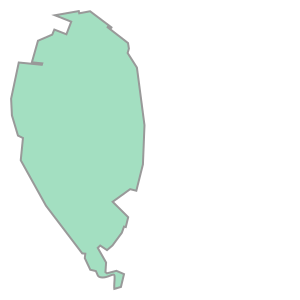

In [9]:
# This cell loads and plots the wetlands polygon. If no output, check your polygon
poly = gpd.read_file("../Supplementary_data/DEA_Wetlands_Insight_Tool/hird.shp")
poly.geometry[0]

In [10]:
# Specifying coordinate reference system of the polygon.
gpgon = datacube.utils.geometry.Geometry(poly.geometry[0], crs=poly.crs)

In [124]:
# Select time period. Consistent data is available from 01-09-1987.
time = ("2014-01-01", "2025-01-01")
# time = ('1985-01-01', '2024-01-01')

### Load and mask Landsat data

In [125]:
# Define which spectral bands are being used in the analysis
bands = [
    f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")
]

# Load Landsat 5, 7 and 8 data. Not including Landsat 7 SLC off period (31-05-2003 to 06-04-2022).
ds = dea_tools.datahandling.load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    ls7_slc_off=False,
    measurements=bands,
    geopolygon=gpgon,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    resampling={"fmask": "nearest", "*": "bilinear"},
    time=time,
    group_by="solar_day",
    dask_chunks={"time":1, "x": 2048, "y": 2048},
)

# Load into memory using Dask
ds.load()

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 498 time steps as a dask array


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 93MB
Dimensions:       (time: 498, y: 127, x: 61)
Coordinates:
  * time          (time) datetime64[ns] 4kB 2014-01-05T00:10:35.094128 ... 20...
  * y             (y) float64 1kB -3.968e+06 -3.968e+06 ... -3.972e+06
  * x             (x) float64 488B 1.09e+06 1.09e+06 ... 1.091e+06 1.091e+06
    spatial_ref   int32 4B 3577
Data variables:
    nbart_blue    (time, y, x) float32 15MB 791.0 728.0 707.0 ... 526.0 543.0
    nbart_green   (time, y, x) float32 15MB 1.097e+03 1.025e+03 ... 774.0 785.0
    nbart_red     (time, y, x) float32 15MB 1.422e+03 1.339e+03 ... 882.0 933.0
    nbart_nir     (time, y, x) float32 15MB 2.151e+03 2.009e+03 ... 1.498e+03
    nbart_swir_1  (time, y, x) float32 15MB 3.506e+03 3.378e+03 ... 2.189e+03
    nbart_swir_2  (time, y, x) float32 15MB 2.41e+03 2.291e+03 ... 1.59e+03
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

### Load Water Observations and Fractional Cover datasets

In [138]:
ds_wo = dc.load(
    "ga_ls_wo_3", resampling="nearest", group_by="solar_day", like=ds, dask_chunks={"time":1, "x": 2048, "y": 2048}
)
ds_fc = dc.load(
    "ga_ls_fc_3", resampling="nearest", group_by="solar_day", like=ds, dask_chunks={"time":1, "x": 2048, "y": 2048}
)

# Load data into memory
ds_wo.load()
ds_fc.load()

<xarray.Dataset> Size: 29MB
Dimensions:      (time: 939, y: 127, x: 61)
Coordinates:
  * time         (time) datetime64[ns] 8kB 2014-01-05T00:10:35.094128 ... 202...
  * y            (y) float64 1kB -3.968e+06 -3.968e+06 ... -3.972e+06 -3.972e+06
  * x            (x) float64 488B 1.09e+06 1.09e+06 ... 1.091e+06 1.091e+06
    spatial_ref  int32 4B 3577
Data variables:
    bs           (time, y, x) uint8 7MB 12 9 11 15 19 16 ... 25 14 18 29 25 30
    pv           (time, y, x) uint8 7MB 7 5 7 13 10 6 7 ... 32 31 32 33 29 15 13
    npv          (time, y, x) uint8 7MB 80 85 81 71 70 77 ... 42 52 47 40 59 56
    ue           (time, y, x) uint8 7MB 9 10 10 9 8 8 9 ... 14 14 15 13 14 16 13
Attributes:
    crs:           PROJCS["GDA94 / Australian Albers",GEOGCS["GDA94",DATUM["G...
    grid_mapping:  spatial_ref

### Locate and remove any observations which aren't in all three datasets

In [139]:
missing = set()
for t1, t2 in itertools.product(
    [ds_fc.time.values, ds_wo.time.values, ds.time.values], repeat=2
):
    missing_ = set(t1) - set(t2)
    missing |= missing_

ds_fc = ds_fc.sel(time=[t for t in ds_fc.time.values if t not in missing])
ds = ds.sel(time=[t for t in ds.time.values if t not in missing])
ds_wo = ds_wo.sel(time=[t for t in ds_wo.time.values if t not in missing])

## Calculate Tasseled Cap Wetness from the Landsat data

In [140]:
tcw = dea_tools.bandindices.calculate_indices(
    ds, index="TCW", collection="ga_ls_3", normalise=False, drop=True, inplace=False
)

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


### Divide Fractional Cover by 100

In [141]:
bs = ds_fc.bs / 100
pv = ds_fc.pv / 100
npv = ds_fc.npv / 100

### Generate the WIT raster bands

In [142]:
rast_names = ["pv", "npv", "bs", "wet", "water"]
output_rast = {n: xr.zeros_like(bs) for n in rast_names}

output_rast["bs"].values[:] = bs
output_rast["pv"].values[:] = pv
output_rast["npv"].values[:] = npv

## Masking and thresholding

In [143]:
# Rasterise the shapefile where poly is the vector data and pv is the xarray template
poly_raster = xr_rasterize(poly, pv) > 0

# Mask includes No data, Non contiguous data, Cloud shadow, Cloud, and water.
# See https://knowledge.dea.ga.gov.au/notebooks/DEA_products/DEA_Water_Observations/#Understanding-WOs-bit-flags for more detail.
mask = (ds_wo.water & 0b01100011) == 0
mask &= poly_raster

# Set open water to water present and classified as water as per Water Observations and bit flags
open_water = ds_wo.water & (1 << 7) > 0

# Set wet pixels where not masked and above threshold of -350
wet = tcw.where(mask).TCW > -350

In [144]:
# Adding wet and water values to output raster

# TCW
output_rast["wet"].values[:] = wet.values.astype(float)
for name in rast_names[:3]:
    output_rast[name].values[wet.values] = 0

# WO
output_rast["water"].values[:] = open_water.values.astype(float)
for name in rast_names[:4]:
    output_rast[name].values[open_water.values] = 0

In [145]:
# Masking again
ds_wit = xr.Dataset(output_rast).where(mask)

Mask entire observations where the polygon is more than 10% masked:

In [146]:
# Calculate percentage missing
pc_missing = (~mask).where(poly_raster).mean(dim=["x", "y"])

ds_wit = ds_wit.where(pc_missing < 0.1)

The WIT results are now computed. All that's left is to normalise them.

### Normalise Fractional Cover Values in WIT result

In [173]:
# Convert ds_wit: XArray.Dataset to polygon_base_df: pandas.DataFrame

polygon_base_df = pd.DataFrame()
polygon_base_df["date"] = ds_wit.time.values

for band in rast_names:
    polygon_base_df[band] = ds_wit[band].mean(dim=["x", "y"])

In [174]:
polygon_base_df = dea_tools.wetlands.normalise_wit(polygon_base_df)

### Create WIT Plot

In [175]:
polygon_name = "Hird Swamp"
png_name = polygon_name  # file will be png_name.png

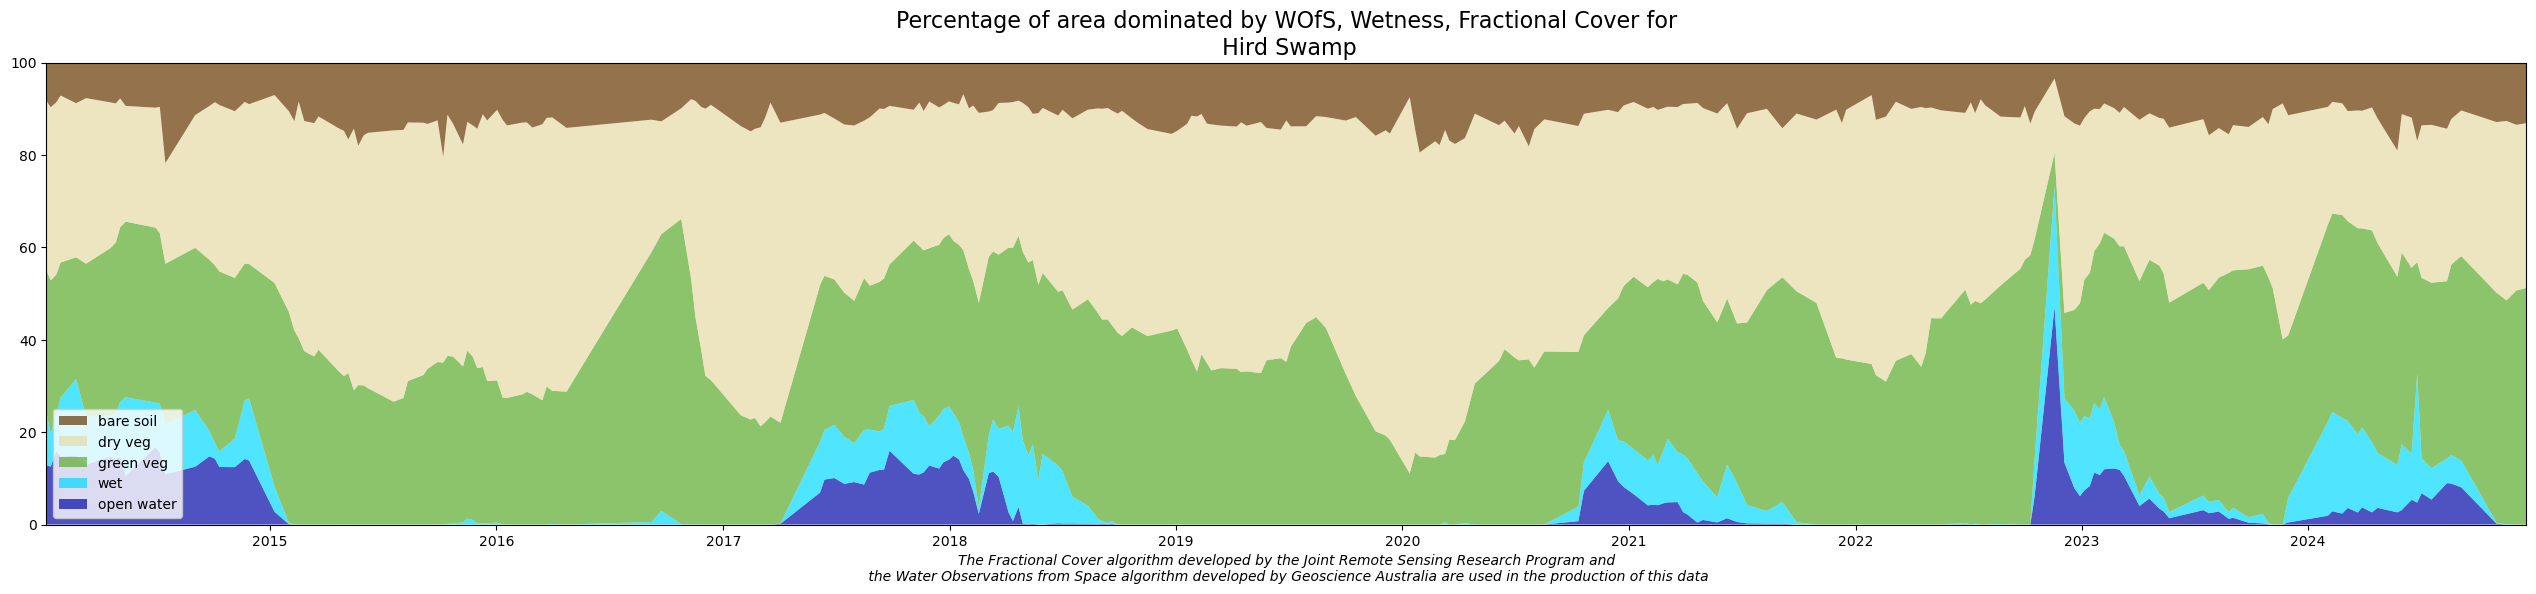

In [176]:
dea_tools.wetlands.display_wit_stack_with_df(polygon_base_df, polygon_name, png_name, x_axis_labels="years")

### Create WIT Comma-separated values (CSV) output file

In [151]:
polygon_base_df.reset_index(drop=True, inplace=True)

In [152]:
polygon_base_df.set_index('date', inplace=True)

In [153]:
polygon_base_df.head()

,index,pv,npv,bs,wet,water,veg_areas,overall_veg_num,norm_bs,norm_pv,norm_npv,off_value
date,,,,,,,,,,,,
2014-01-05 00:10:35.094128,0,0.302159,0.362029,0.081384,0.114499,0.128604,0.756897,0.745571,0.082620,0.306749,0.367528,0
2014-01-12 00:16:38.441350,1,0.326980,0.369096,0.095408,0.071147,0.125285,0.803568,0.791483,0.096864,0.331972,0.374731,0
2014-01-21 00:10:22.639905,2,0.300780,0.367310,0.084866,0.077162,0.158473,0.764364,0.752956,0.086152,0.305337,0.372875,0
2014-01-28 00:16:31.184708,3,0.288295,0.356392,0.070370,0.126921,0.147486,0.725592,0.715056,0.071407,0.292542,0.361643,0
2014-02-22 00:10:00.687733,5,0.259674,0.328546,0.086845,0.166356,0.148724,0.684920,0.675065,0.088113,0.263465,0.333342,0


In [154]:
#set output csv name to polygon name
csv_name = polygon_name
#write WIT dataframe to csv without including the index row
polygon_base_df.to_csv(f"{polygon_name}.csv", index=False)

# Plot

In [155]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import imageio
import shutil

In [156]:
# making a copy in case i ruin it, means i don't have to re-run it
ds_wit_copy = ds_wit.dropna(dim="time", how="all")
ds_wit_copy

<xarray.Dataset> Size: 80MB
Dimensions:      (time: 258, y: 127, x: 61)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2014-01-05T00:10:35.094128 ... 202...
  * y            (y) float64 1kB -3.968e+06 -3.968e+06 ... -3.972e+06 -3.972e+06
  * x            (x) float64 488B 1.09e+06 1.09e+06 ... 1.091e+06 1.091e+06
    spatial_ref  int32 4B 3577
Data variables:
    pv           (time, y, x) float64 16MB nan nan nan nan ... nan nan nan nan
    npv          (time, y, x) float64 16MB nan nan nan nan ... nan nan nan nan
    bs           (time, y, x) float64 16MB nan nan nan nan ... nan nan nan nan
    wet          (time, y, x) float64 16MB nan nan nan nan ... nan nan nan nan
    water        (time, y, x) float64 16MB nan nan nan nan ... nan nan nan nan

In [157]:
fraction_sum = ds_wit_copy['pv'] + ds_wit_copy['npv'] + ds_wit_copy['bs']
ds_wit_copy['pv'] = ds_wit_copy['pv'] / fraction_sum
ds_wit_copy['npv'] = ds_wit_copy['npv'] / fraction_sum
ds_wit_copy['bs'] = ds_wit_copy['bs'] / fraction_sum

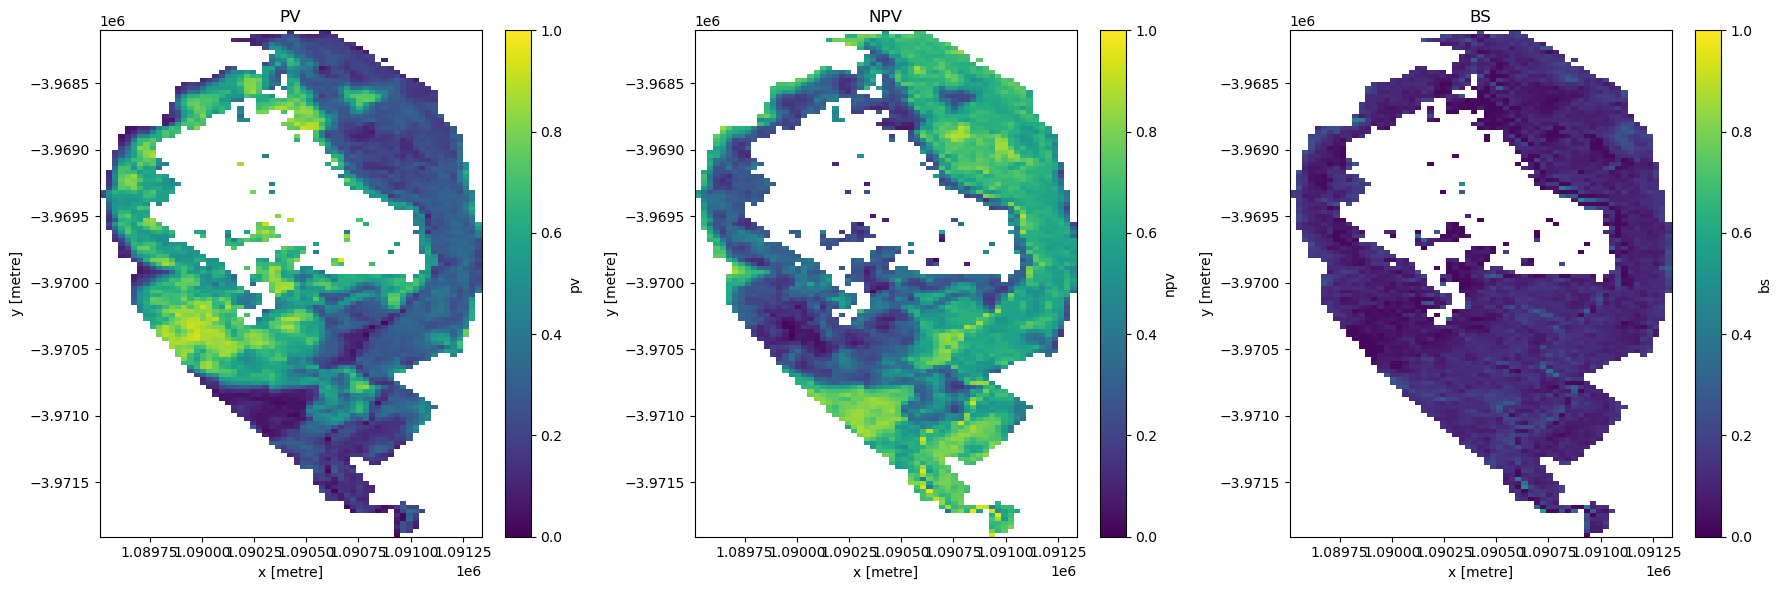

In [158]:
# this is just a sanity check to see that the fractional cover values make sense

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot each of the variables in its respective subplot
ds_wit_copy['pv'].isel(time=0).plot(ax=axes[0], vmin=0, vmax=1, cmap='viridis')
axes[0].set_title('PV')

ds_wit_copy['npv'].isel(time=0).plot(ax=axes[1], vmin=0, vmax=1, cmap='viridis')
axes[1].set_title('NPV')

ds_wit_copy['bs'].isel(time=0).plot(ax=axes[2], vmin=0, vmax=1, cmap='viridis')
axes[2].set_title('BS')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

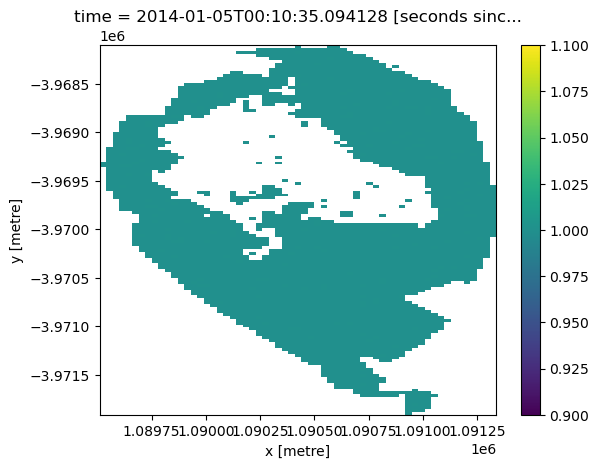

In [159]:
# another sanity check, where we check that all fc values equal 1
fraction_sum = ds_wit_copy['pv'].isel(time=0) + ds_wit_copy['npv'].isel(time=0) + ds_wit_copy['bs'].isel(time=0)
fraction_sum.plot()

In [160]:
# this sorts the fractional cover values into their classes

def classify_pixel(pv, npv, bs):
    if pv > 2/3:
        return 8  # pv
    elif npv > 2/3:
        return 0  # ng
    elif bs > 2/3:
        return 4  # bs
    elif npv > 1/3 and bs > 1/3 and pv < 1/3:
        return 1  # ng_bs
    elif npv > 1/3 and pv > 1/3 and bs < 1/3:
        return 3  # ng_pv
    elif npv > 1/3 and pv < 1/3 and bs < 1/3:
        return 2  # ng_mix
    elif bs > 1/3 and pv > 1/3 and npv < 1/3:
        return 6  # bs_pv
    elif bs > 1/3 and pv < 1/3 and npv < 1/3:
        return 5  # bs_mix
    elif pv > 1/3 and npv < 1/3 and bs < 1/3:
        return 7  # pv_mix
    return -1 

# Apply the classification function to the dataset across all time, y, x
fc_class = xr.apply_ufunc(
    classify_pixel,
    ds_wit_copy['pv'], ds_wit_copy['npv'], ds_wit_copy['bs'],
    vectorize=True,
)

fc_class = fc_class.where(fc_class != -1, np.nan)

# Add the new classification band to the dataset
ds_wit_copy['fc_class'] = fc_class

/env/lib/python3.10/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in classify_pixel (vectorized)
  outputs = ufunc(*inputs)


In [161]:
# this is a colour map for mapping fc only
color_dict = {
    0: "#F1E8C9",  # ng
    1: "#C0AB86",  # ng_bs
    2: "#D6D2A7",  # ng_mix
    3: "#BCD495",  # ng_pv
    4: "#93724C",  # bs
    5: "#9C895D",  # bs_mix
    6: "#8F9C5C",  # bs_pv
    7: "#9DBD74",  # pv_mix
    8: "#8CC46B",  # pv
}

# Create a ListedColormap and a corresponding norm
cmap = mcolors.ListedColormap([color_dict[i] for i in range(9)], name='fc_class_cmap')
bounds = list(color_dict.keys()) + [len(color_dict)]  # Bounds for each color
norm = mcolors.BoundaryNorm(bounds, cmap.N)

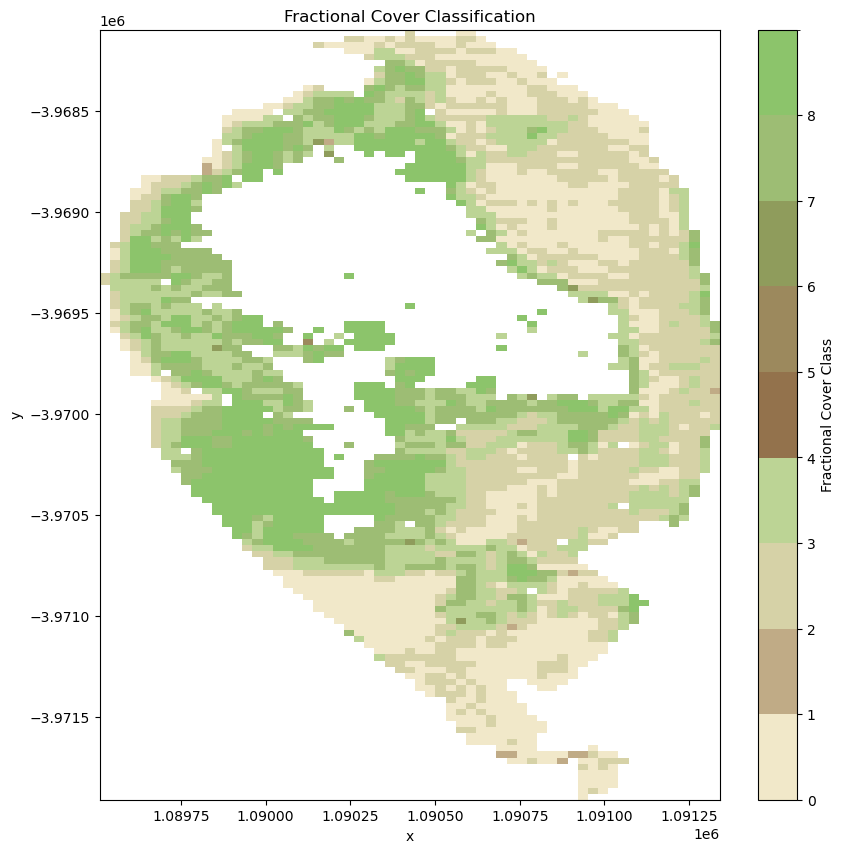

In [162]:
# lets test it

time_step = ds_wit_copy['fc_class'].isel(time=2)

# Plotting the fc_class variable with the colormap
plt.figure(figsize=(10, 10))
fc_class_plot = time_step.plot.imshow(
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        'ticks': list(color_dict.keys()),
        'label': 'Fractional Cover Class'
    }
)
plt.title("Fractional Cover Classification")
plt.show()

In [163]:
# here we are making a brand new band called wetland that combines all the fc classes with the water and wet classes
# i.e. water == 10, wet == 9, all other areas retain original fc class
wetland = ds_wit_copy['fc_class'].where((ds_wit_copy['water'] == 0) | ds_wit_copy['water'].isnull(), 10)
ds_wit_copy['wetland'] = wetland
wetland = ds_wit_copy['wetland'].where((ds_wit_copy['wet'] == 0) | ds_wit_copy['wet'].isnull(), 9)
ds_wit_copy['wetland'] = wetland


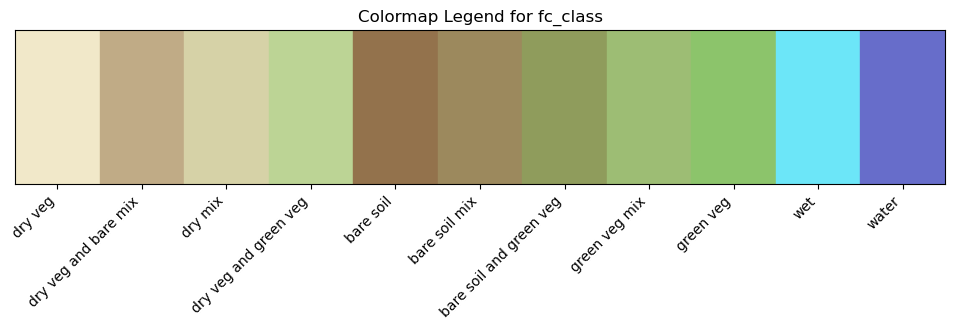

In [164]:
class_labels = [
    "dry veg", "dry veg and bare mix", "dry mix", "dry veg and green veg",
    "bare soil", "bare soil mix", "bare soil and green veg", "green veg mix",
    "green veg", "wet", "water"
]

# Create a ListedColormap with the specified colors
cmap = mcolors.ListedColormap([
    "#F1E8C9",  # ng
    "#C0AB86",  # ng_bs
    "#D6D2A7",  # ng_mix
    "#BCD495",  # ng_pv
    "#93724C",  # bs
    "#9C895D",  # bs_mix
    "#8F9C5C",  # bs_pv
    "#9DBD74",  # pv_mix
    "#8CC46B",  # pv
    "#6ce6f8",  # wet
    "#676dca"   # water
])

norm = mcolors.Normalize(vmin=0, vmax=10)


# Create a figure to display the colormap
fig, ax = plt.subplots(figsize=(12, 2))
# Create a bar plot with each class's color
for i, color in enumerate(cmap.colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))

# Formatting the plot
ax.set_xticks(np.arange(len(class_labels)) + 0.5)
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.set_yticks([])
ax.set_xlim(0, len(class_labels))
plt.title("Colormap Legend for fc_class")
plt.show()

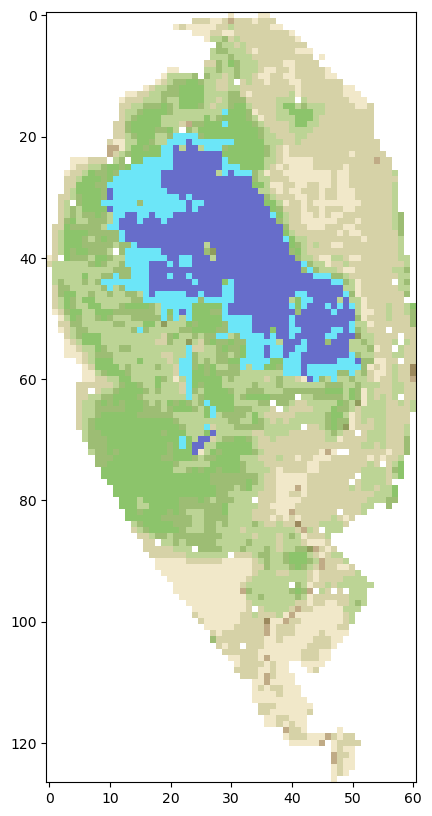

In [165]:
time_step = ds_wit_copy['wetland'].isel(time=1)

# Define the colormap with your custom colors
cmap = mcolors.ListedColormap([
    "#F1E8C9",  # ng
    "#C0AB86",  # ng_bs
    "#D6D2A7",  # ng_mix
    "#BCD495",  # ng_pv
    "#93724C",  # bs
    "#9C895D",  # bs_mix
    "#8F9C5C",  # bs_pv
    "#9DBD74",  # pv_mix
    "#8CC46B",  # pv
    "#6ce6f8", #wet
    "#676dca" # water
])

# Create a BoundedNorm to ensure correct mapping of data to the colormap
norm = mcolors.Normalize(vmin=0, vmax=10)

# Plot the data using imshow with the custom colormap
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(time_step, cmap=cmap)

# Show the plot
plt.show()

In [100]:
# code to save a timestep as a geotiff
wetland_date = ds_wit_copy['wetland'].isel(time=0)  
wetland_date.rio.write_crs("EPSG:3577", inplace=True)
date_str = str(wetland_date.time.values)[:10]  # extract date string
wetland_date.rio.to_raster(f"wetland_{date_str}.tif")

In [109]:
# if you want to save them all 
for t in ds_wit_copy.time:
    wetland_time_step = ds_wit_copy['wetland'].sel(time=t)
    date_str = str(t.values)[:10]  # Extract date as string
    wetland_time_step.rio.to_raster(f"wetland_{date_str}.tif")

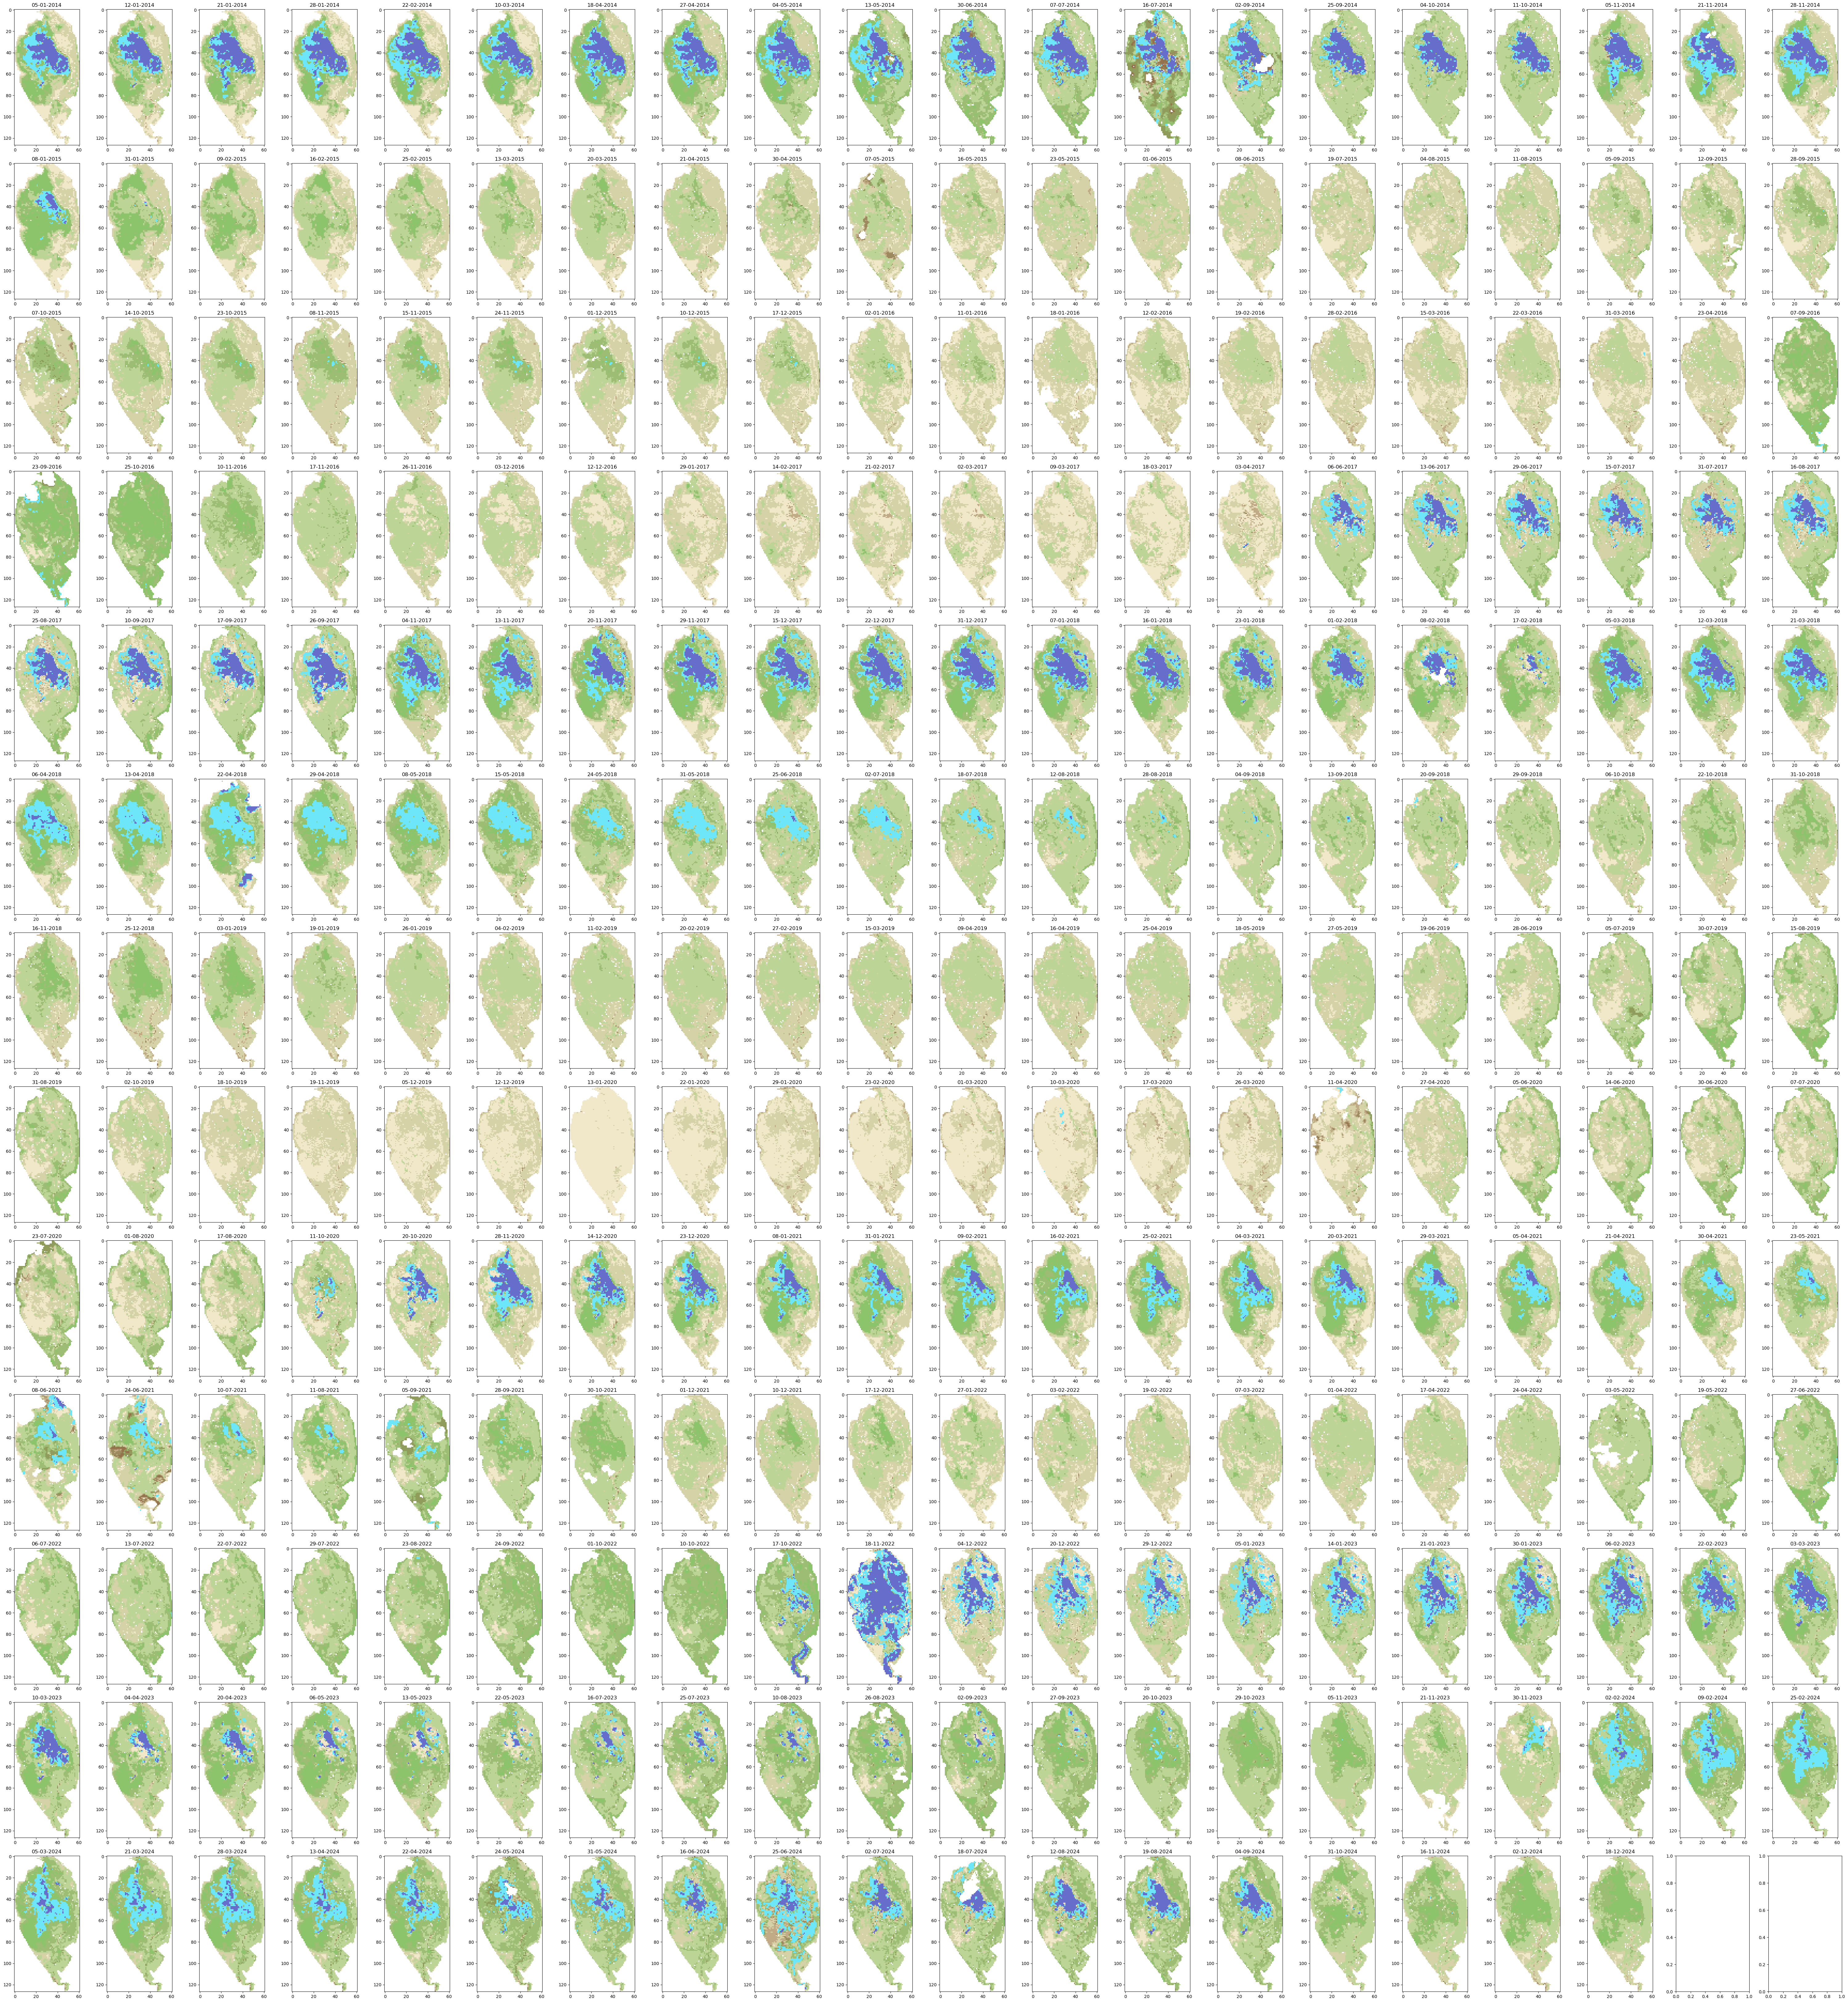

In [169]:
# to make one big plot

num_time_steps = ds_wit_copy.sizes['time']

num_columns = 20 # change this depending on timesteps
num_rows = (num_time_steps + num_columns - 1) // num_columns  # Calculate the number of rows

fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 3, num_rows * 5))

if num_rows == 1:
    axes = axes.reshape(1, num_columns)
elif num_columns == 1:
    axes = axes.reshape(num_rows, 1)

for t in range(num_time_steps):
    time_step = ds_wit_copy['wetland'].isel(time=t)
    time_ns = ds_wit_copy['time'].isel(time=t).values.item()
    time_date = pd.to_datetime(time_ns, unit='ns')
    time_date_str = time_date.strftime('%d-%m-%Y')
    row_idx = t // num_columns 
    col_idx = t % num_columns
    cax = axes[row_idx, col_idx].imshow(time_step, cmap=cmap, norm=norm, interpolation='none')
    axes[row_idx, col_idx].set_title(f'{time_date_str}')

plt.tight_layout()
plt.savefig('wetland_time_steps.png', dpi=300)  
plt.show()

In [168]:
# make a gif

# create a directory to save the frames
os.makedirs('frames', exist_ok=True)

# loop through each time step, creating and saving a frame
num_time_steps = ds_wit_copy.sizes['time']
frames = []

for t in range(num_time_steps):
    fig, ax = plt.subplots(figsize=(6, 6))  # adjust size as needed
    time_step = ds_wit_copy['wetland'].isel(time=t)
    
    time_ns = ds_wit_copy['time'].isel(time=t).values.item()
    time_date = pd.to_datetime(time_ns, unit='ns')
    time_date_str = time_date.strftime('%d-%m-%Y')
    
    cax = ax.imshow(time_step, cmap=cmap, norm=norm, interpolation='none')
    ax.set_title(f'Time: {time_date_str}')
    
    frame_path = f'frames/frame_{t:03d}.png'
    plt.savefig(frame_path)
    frames.append(frame_path)
    plt.close(fig)  

# make the gif
with imageio.get_writer('wetland_animation.gif', mode='I', duration=0.7, loop=0) as writer:
    for frame_path in frames:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print("GIF saved as 'wetland_animation.gif'")

# clean up
# for frame_path in frames:
#     os.remove(frame_path)
shutil.rmtree('frames')

/tmp/ipykernel_346/2814792958.py:29: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)


GIF saved as 'wetland_animation.gif'


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Citations** &mdash; If you use the DEA Notebooks and Tools repository in your work, please reference
it with the following citation:

> Krause, C., Dunn, B., Bishop-Taylor, R., Adams, C., Burton, C., Alger,
> M., Chua, S., Phillips, C., Newey, V., Kouzoubov, K., Leith, A.,
> Ayers, D., Hicks, A., DEA Notebooks contributors 2021. Digital Earth
> Australia notebooks and tools repository. Geoscience Australia,
> Canberra. <https://doi.org/10.26186/145234>

To cite this notebooks' dataset and research papers in your work you can use the [Publications](#Publications) at the top of this notebook.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** July 2024

**Compatible datacube version:** 

In [24]:
print(datacube.__version__)

1.8.18


## Tags